In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import History
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [2]:

# 2. Load Dataset
# ==============================
df = pd.read_csv("telecom_customer_churn (1).csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

First 5 rows:
   customer_id  gender  age  tenure_months  monthly_charges  total_charges  \
0        10001    Male   68             35          1663.21       53005.27   
1        10002  Female   23             22          4395.65       84400.80   
2        10003    Male   23             43          3461.70      120260.56   
3        10004    Male   20             15          4044.40      103227.86   
4        10005    Male   24             60          1477.20       58348.72   

    contract_type internet_service  support_calls payment_method  churn  
0  Month-to-month              DSL              0     Electronic      0  
1  Month-to-month            Fiber              5           Bank      1  
2        One year            Fiber              1           Card      0  
3  Month-to-month            Fiber              3           Bank      0  
4        Two year              DSL              1         Mailed      0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 ent

In [3]:

# 3. Basic Data Cleaning


# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove customerID column if exists (not useful for ML)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

In [4]:
# 4. Handle Missing Values


# Convert TotalCharges to numeric if it's object type
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill numerical missing values with median
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_456\2620083362.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_456\2620083362.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [5]:
# 5. Encode Categorical Variables

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [6]:
# 6. Define Features and Target

X = df.drop('churn', axis=1)
y = df['churn']




In [7]:
X

,customer_id,gender,age,tenure_months,monthly_charges,total_charges,contract_type,internet_service,support_calls,payment_method
0,10001,1,68,35,1663.21,53005.27,0,0,0,2
1,10002,0,23,22,4395.65,84400.80,0,1,5,0
2,10003,1,23,43,3461.70,120260.56,1,1,1,1
3,10004,1,20,15,4044.40,103227.86,0,1,3,0
4,10005,1,24,60,1477.20,58348.72,2,0,1,3
...,...,...,...,...,...,...,...,...,...,...
1495,11496,1,40,19,4042.34,100294.62,0,0,1,1
1496,11497,0,43,43,3754.62,15370.42,2,0,4,3
1497,11498,0,21,20,3167.51,137202.64,0,1,2,2
1498,11499,1,35,68,2594.44,101140.86,0,0,1,0


In [8]:
y

0       0
1       1
2       0
3       0
4       0
       ..
1495    0
1496    0
1497    0
1498    0
1499    0
Name: churn, Length: 1500, dtype: int64

In [9]:

# 7. Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# 8. Scaling (Optional for Decision Tree)

# Decision Trees do not require scaling,
# but including for learning purpose

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# 9. Train Decision Tree Model
# ==============================

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42,
    min_samples_split=20,
    min_samples_leaf=10,
    ccp_alpha=0.5
)

model.fit(X_train, y_train)




,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:

# 10. Predictions


y_pred = model.predict(X_test)


In [13]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [14]:
# 11. Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nF1 Score :", f1_score(y_test, y_pred))



Accuracy: 0.82

Confusion Matrix:
 [[246   0]
 [ 54   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      1.00      0.90       246
           1       0.00      0.00      0.00        54

    accuracy                           0.82       300
   macro avg       0.41      0.50      0.45       300
weighted avg       0.67      0.82      0.74       300


F1 Score : 0.0


c:\Users\User\Downloads\007\.conda\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\Downloads\007\.conda\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\Downloads\007\.conda\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

# now by using grid search

In [15]:
dt = DecisionTreeClassifier(random_state=42)

In [33]:
# 8. Define Parameter Grid

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha': [0.2, 0.5, 1.0, 5.0]
}

In [34]:
# 9. Apply Grid Search
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'ccp_alpha': [0.2, 0.5, ...], 'criterion': ['gini', 'entropy'], 'max_depth': [None, 3, ...], 'max_features': [None, 'sqrt', ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [35]:
# 10. Best Parameters

print("Best Parameters Found:")
print(grid_search.best_params_)

Best Parameters Found:
{'ccp_alpha': 0.2, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [36]:
# 11. Best Model Evaluation
best_model = grid_search.best_estimator_

y_pred1 = best_model.predict(X_test)
y_prob1 = best_model.predict_proba(X_test)[:,1]

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)
print("\nAccuracy:", accuracy_score(y_test, y_pred1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("\nClassification Report:\n", classification_report(y_test, y_pred1))
print("\nF1 Score :", f1_score(y_test, y_pred1))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob1))


Accuracy: 0.9133333333333333

Confusion Matrix:
 [[220  26]
 [  0  54]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.89      0.94       246
           1       0.68      1.00      0.81        54

    accuracy                           0.91       300
   macro avg       0.84      0.95      0.88       300
weighted avg       0.94      0.91      0.92       300


F1 Score : 0.8059701492537313
ROC-AUC  : 0.9532520325203252


# now do it by ann 

In [21]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [22]:
# 7. Build ANN Model

model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

# Output Layer (Binary Classification)
model.add(Dense(1, activation='sigmoid'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



c:\Users\User\Downloads\007\.conda\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:

# 8. Early Stopping (Prevents Overfitting)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


# 9. Train Model

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)






Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7635 - loss: 0.5724 - val_accuracy: 0.8417 - val_loss: 0.4425
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8021 - loss: 0.4884 - val_accuracy: 0.8458 - val_loss: 0.3760
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8167 - loss: 0.4208 - val_accuracy: 0.8667 - val_loss: 0.3272
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8323 - loss: 0.3858 - val_accuracy: 0.8875 - val_loss: 0.2939
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8500 - loss: 0.3467 - val_accuracy: 0.8958 - val_loss: 0.2671
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8479 - loss: 0.3196 - val_accuracy: 0.9083 - val_loss: 0.2460
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8833 - loss: 0.2842 - val_accuracy: 0.9042 - val_loss: 0.2313
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8698 - loss: 0.2826 - val_accuracy: 0.8917 - val_loss

In [24]:
# 10. Predictions

y_prob = model.predict(X_test)

y_pred2 = (y_prob > 0.5).astype(int)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [25]:
# 11. Evaluation Metrics

print("\n===== ANN Evaluation =====")
print("Accuracy :", accuracy_score(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2))
print("Recall   :", recall_score(y_test, y_pred2))
print("F1 Score :", f1_score(y_test, y_pred2))





===== ANN Evaluation =====
Accuracy : 0.9633333333333334
Precision: 0.9056603773584906
Recall   : 0.8888888888888888
F1 Score : 0.897196261682243


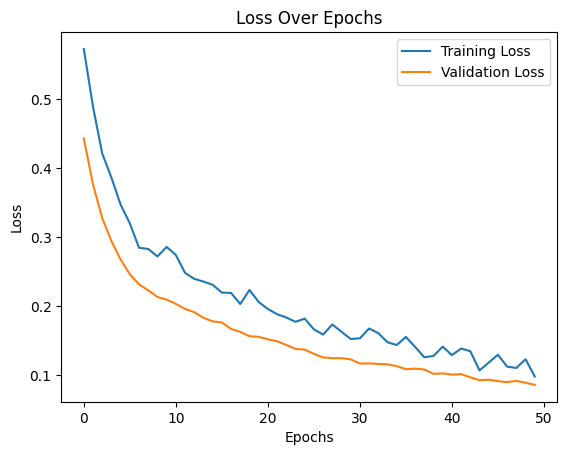

In [26]:
# Plot the loss curves for training and validation
import matplotlib.pyplot as plt
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# now do it by optuna

In [27]:
# 3. Define Optuna Objective Function

def objective(trial):
    
    model = Sequential()
    
    # Tune number of hidden layers
    n_layers = trial.suggest_int("n_layers", 1, 3)
    
    for i in range(n_layers):
        units = trial.suggest_int(f"units_l{i}", 16, 128)
        dropout_rate = trial.suggest_float(f"dropout_l{i}", 0.1, 0.5)
        
        if i == 0:
            model.add(Dense(units, activation='relu', input_dim=X_train.shape[1]))
        else:
            model.add(Dense(units, activation='relu'))
        
        model.add(Dropout(dropout_rate))
    
    # Output layer
    model.add(Dense(1, activation='sigmoid'))
    
    # Tune learning rate
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy'
    )
    
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=0
    )
    
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=trial.suggest_categorical("batch_size", [16, 32, 64]),
        verbose=0,
        callbacks=[early_stop]
    )
    
    y_pred_prob3 = model.predict(X_test, verbose=0)
    auc = roc_auc_score(y_test, y_pred_prob3)
    
    return auc

In [28]:
# 4. Run Optuna Study
import optuna
from tensorflow.keras.optimizers import Adam

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best Trial:")
print(study.best_trial.params)

c:\Users\User\Downloads\007\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-02 11:17:04,665] A new study created in memory with name: no-name-98053c6f-d317-4aff-8c87-75818af0c37a
c:\Users\User\Downloads\007\.conda\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-03-02 11:17:09,313] Trial 0 finished with value: 0.9948057813911472 and parameters: {'n_layers': 1, 'units_l0': 90, 'dropout_l0': 0.10024386224057334, 'learning_rate': 0.005988257103430025, 'batch_size': 32}. Best is trial 0 with value: 0.9948057813911472.
c:\Users\User\Downl

Best Trial:
{'n_layers': 1, 'units_l0': 17, 'dropout_l0': 0.38567483510529743, 'learning_rate': 0.009958818803918888, 'batch_size': 32}


In [31]:
# 5. Train Final Model with Best Params

best_params = study.best_trial.params

final_model = Sequential()

for i in range(best_params["n_layers"]):
    units = best_params[f"units_l{i}"]
    dropout_rate = best_params[f"dropout_l{i}"]
    
    if i == 0:
        final_model.add(Dense(units, activation='relu', input_dim=X_train.shape[1]))
    else:
        final_model.add(Dense(units, activation='relu'))
    
    final_model.add(Dropout(dropout_rate))

final_model.add(Dense(1, activation='sigmoid'))

final_model.compile(
    optimizer=Adam(learning_rate=best_params["learning_rate"]),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

final_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=best_params["batch_size"],
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)




Epoch 1/50


c:\Users\User\Downloads\007\.conda\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7875 - loss: 0.5045 - val_accuracy: 0.8583 - val_loss: 0.3246
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8417 - loss: 0.3541 - val_accuracy: 0.8833 - val_loss: 0.2618
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8667 - loss: 0.3067 - val_accuracy: 0.8958 - val_loss: 0.2372
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8708 - loss: 0.2972 - val_accuracy: 0.9042 - val_loss: 0.2265
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8635 - loss: 0.2804 - val_accuracy: 0.9042 - val_loss: 0.2170
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8854 - loss: 0.2722 - val_accuracy: 0.9125 - val_loss: 0.2069
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8865 - loss: 0.2642 - val_accuracy: 0.9042 - val_loss: 0.1984
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8958 - loss: 0.2307 - val_accuracy: 0.9167 - val_loss: 0.1864
Ep

In [32]:
# 6. Final Evaluation

y_prob3 = final_model.predict(X_test)
y_pred3 = (y_prob3 > 0.5).astype(int)

from sklearn.metrics import accuracy_score, f1_score

print("\nFinal Accuracy:", accuracy_score(y_test, y_pred3))
print("Final F1 Score:", f1_score(y_test, y_pred3))
print("Final ROC-AUC :", roc_auc_score(y_test, y_prob))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

Final Accuracy: 0.98
Final F1 Score: 0.9423076923076923
Final ROC-AUC : 0.9914935260463716
